# ML Preprocessing

## Objective

Prepare the cleaned hotel reservation dataset for machine learning model development.

Tasks:

* Load dataset
* Understand structure
* Inspect target variable
* Review feature types


In [39]:
import pandas as pd

df = pd.read_csv("../data/Cleaned_Hotel_Reservations.csv")

print("Shape:", df.shape)
df.head()

Shape: (35555, 25)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,room_type_reserved,lead_time,arrival_year,arrival_month,...,avg_price_per_room,no_of_special_requests,booking_status,arrival_date_full,descriptive_room_type,descriptive_meal_plan,total_guests,total_nights,revenue_per_night,booking_segment
0,INN00001,2,0,1,2,Meal Plan 1,Room_Type 1,224,2017,10,...,65.00,0,1,02-10-2017,Standard Room,"Breakfast, Lunch & Dinner",2,3,21.666667,Long-Term
1,INN00002,2,0,2,3,Not Selected,Room_Type 1,5,2018,11,...,106.68,1,1,06-11-2018,Standard Room,No Meal Plan,2,5,21.336000,Last-Minute
2,INN00003,1,0,2,1,Meal Plan 1,Room_Type 1,1,2018,2,...,60.00,0,0,28-02-2018,Standard Room,"Breakfast, Lunch & Dinner",1,3,20.000000,Last-Minute
3,INN00004,2,0,0,2,Meal Plan 1,Room_Type 1,211,2018,5,...,100.00,0,0,20-05-2018,Standard Room,"Breakfast, Lunch & Dinner",2,2,50.000000,Long-Term
4,INN00005,2,0,1,1,Not Selected,Room_Type 1,48,2018,4,...,94.50,0,0,11-04-2018,Standard Room,No Meal Plan,2,2,47.250000,Medium-Term


# Dataset Inspection

Analyze dataset structure, data types and target distribution.


In [40]:
df.info()

df.describe()

print(df["booking_status"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35555 entries, 0 to 35554
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            35555 non-null  object 
 1   no_of_adults                          35555 non-null  int64  
 2   no_of_children                        35555 non-null  int64  
 3   no_of_weekend_nights                  35555 non-null  int64  
 4   no_of_week_nights                     35555 non-null  int64  
 5   type_of_meal_plan                     35555 non-null  object 
 6   room_type_reserved                    35555 non-null  object 
 7   lead_time                             35555 non-null  int64  
 8   arrival_year                          35555 non-null  int64  
 9   arrival_month                         35555 non-null  int64  
 10  arrival_date                          35555 non-null  int64  
 11  market_segment_

# Feature Selection

Remove identifier columns and redundant features that do not contribute to prediction.


In [41]:
columns_to_drop = [
    "Booking_ID",
    "arrival_date_full",
    "descriptive_room_type",
    "descriptive_meal_plan"
]

df = df.drop(columns=columns_to_drop)

print(df.shape)

(35555, 21)


# Feature Validation

Verify remaining columns before encoding.


In [42]:
print(df.columns.tolist())

['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status', 'total_guests', 'total_nights', 'revenue_per_night', 'booking_segment']


# Encoding Categorical Variables

Convert categorical variables into numerical format for machine learning.


In [43]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights,revenue_per_night,booking_segment
0,2,0,1,2,0,0,224,2017,10,2,...,0,0,0,65.00,0,1,2,3,21.666667,1
1,2,0,2,3,3,0,5,2018,11,6,...,0,0,0,106.68,1,1,2,5,21.336000,0
2,1,0,2,1,0,0,1,2018,2,28,...,0,0,0,60.00,0,0,1,3,20.000000,0
3,2,0,0,2,0,0,211,2018,5,20,...,0,0,0,100.00,0,0,2,2,50.000000,1
4,2,0,1,1,3,0,48,2018,4,11,...,0,0,0,94.50,0,0,2,2,47.250000,2


# Encoding Verification

Confirm all columns are ready for model training.

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35555 entries, 0 to 35554
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          35555 non-null  int64  
 1   no_of_children                        35555 non-null  int64  
 2   no_of_weekend_nights                  35555 non-null  int64  
 3   no_of_week_nights                     35555 non-null  int64  
 4   type_of_meal_plan                     35555 non-null  int64  
 5   room_type_reserved                    35555 non-null  int64  
 6   lead_time                             35555 non-null  int64  
 7   arrival_year                          35555 non-null  int64  
 8   arrival_month                         35555 non-null  int64  
 9   arrival_date                          35555 non-null  int64  
 10  market_segment_type                   35555 non-null  int64  
 11  repeated_guest 

# Preparing Feature Matrix

Separate independent variables and target variable.

In [45]:
X = df.drop("booking_status", axis=1)

y = df["booking_status"]

print(X.shape)
print(y.shape)

(35555, 20)
(35555,)


# Train-Test Split

Create training and testing datasets for model development.

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(28444, 20)
(7111, 20)


WEEK 3 - MAIN ML PART

# Logistic Regression Model

Objective:
Train a Logistic Regression model to predict hotel booking cancellations.

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# Logistic Regression Accuracy

In [48]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", lr_accuracy)

Accuracy: 0.803403178174659


# Classification Report

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.76      0.62      0.68      2411
           1       0.82      0.90      0.86      4700

    accuracy                           0.80      7111
   macro avg       0.79      0.76      0.77      7111
weighted avg       0.80      0.80      0.80      7111



# Logistic Regression Confusion Matrix

In [50]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[1486  925]
 [ 473 4227]]


# Confusion Matrix Visualization

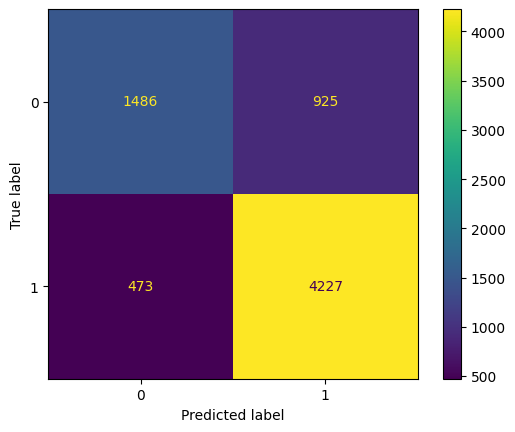

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(cm_lr).plot()
plt.show()

# Logistic Regression ROC AUC

In [52]:
from sklearn.metrics import roc_auc_score

roc_lr = roc_auc_score(y_test, y_pred_lr)

print("ROC AUC:", roc_lr)

ROC AUC: 0.75785173451468


# Decision Tree Model

In [53]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# Decision Tree Predictions

In [54]:
y_pred_dt = dt.predict(X_test)
print(y_pred_dt[:10])

[0 0 0 0 0 0 1 1 1 1]


# Decision Tree Accuracy

In [55]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", dt_accuracy)

Accuracy: 0.86640416256504


In [56]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      2411
           1       0.90      0.90      0.90      4700

    accuracy                           0.87      7111
   macro avg       0.85      0.85      0.85      7111
weighted avg       0.87      0.87      0.87      7111



In [57]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[1953  458]
 [ 492 4208]]
